In [41]:
with open('/u/arego/files_viper.txt') as f:
    lines = f.readlines()
    lines=[int(line.split('.')[0]) for line in lines]

In [49]:
with open('/u/arego/files.txt') as f:
    lines_rav = f.readlines()
    lines_rav=[int(line.split('.')[0]) for line in lines_rav]

In [50]:
len(lines_rav)

23397

In [43]:
import numpy as np

In [44]:
lines=np.array(lines+lines_rav)

In [45]:
values= np.unique(lines, return_counts=True)

In [36]:
files=values[0][values[1]==2]

In [38]:
import os
path='/ptmp/arego/LargeTracks/'
for file in files:
    file_path=f'{path}/{file}.h5'
    if os.path.isfile(file_path):
        os.remove(file_path)

In [47]:
values[1].max()

1

In [48]:
20_000*20

400000

In [51]:
import tempfile

In [55]:
tempfile.gettempprefix()

'tmp'

In [23]:
import os
import matplotlib.pyplot as plt

def plot_file_sizes(dir_path):
    files = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))]
    sizes = [os.path.getsize(f) / (1024*1024*1024) for f in files]  # MB
    plt.hist(sizes, bins=100, edgecolor='black')
    plt.xlabel("File Size (GB)")
    plt.ylabel("Count")
    plt.title(f"File Size Distribution in {dir_path}")
    plt.yscale('log')
    plt.show()


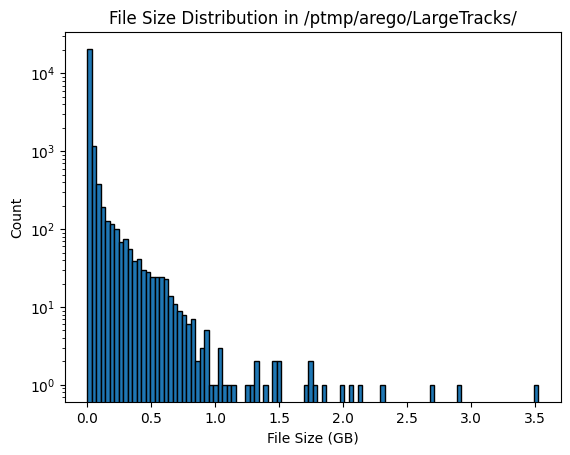

In [24]:
plot_file_sizes('/ptmp/arego/LargeTracks/')

In [39]:
dir_path='/ptmp/arego/LargeTracks/'
files = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))]
sizes = [os.path.getsize(f) / (1024*1024) for f in files] 

In [10]:
import pandas as pd

In [12]:
df_dict={"file":files,
        'size':sizes}

In [14]:
df=pd.DataFrame(df_dict)

In [19]:
df=df.sort_values('size',ascending=False)

In [30]:
display(df[:4]['size'].sum())

11743.369985580444

In [38]:
df['file']

6704      /ptmp/arego/LargeTracks/9798.h5
13060     /ptmp/arego/LargeTracks/5435.h5
8858      /ptmp/arego/LargeTracks/8893.h5
16397     /ptmp/arego/LargeTracks/8556.h5
15596     /ptmp/arego/LargeTracks/1583.h5
                       ...               
7491      /ptmp/arego/LargeTracks/1196.h5
18485    /ptmp/arego/LargeTracks/15482.h5
5441      /ptmp/arego/LargeTracks/7832.h5
20729    /ptmp/arego/LargeTracks/17555.h5
17467    /ptmp/arego/LargeTracks/18826.h5
Name: file, Length: 23293, dtype: object

In [41]:
22842-23293

-451

In [68]:
process_file('/ptmp/arego/LargeTracks/9798.h5',1_000_000)

Processing 9798.h5: 885,568,081 rows in 886 chunks
  Chunk 886/886 (100.0%) - Rows 885,000,000-885,568,081
  Completed! Found 20 unique record_ids


{9798000000000: 1752.969482421875,
 9798000000001: 1053.5872802734375,
 9798000000003: 5308.9150390625,
 9798000000004: 2672.63525390625,
 9798000000007: 359.6100769042969,
 9798000000011: 1463.0072021484375,
 9798000000014: 618.5653686523438,
 9798000000015: 324.15185546875,
 9798000000016: 942.7508544921875,
 9798000000017: 782.9278564453125,
 9798000000018: 0.0,
 9798000000019: 1685.319091796875,
 9798000000021: 301.9606018066406,
 9798000000024: 505.39544677734375,
 9798000000026: 91.00360107421875,
 9798000000027: 787.5086669921875,
 9798000000028: 597.9754638671875,
 9798000000029: 357.7394714355469,
 9798000000030: 3484.22607421875,
 9798000000031: 330.78118896484375}

In [69]:
with pd.HDFStore('/ptmp/arego/LargeTracks/9798.h5') as store:
    print(dir(store))

ValueError: The file '/ptmp/arego/LargeTracks/9798.h5' is already opened, but in read-only mode.  Please close it before reopening in append mode.

In [66]:
def process_file(file_path: str, chunk_size: int = 50000, show_progress: bool = True):
    """Process a single HDF5 file and compute durations for each record_id using chunked processing."""
    file_id = int(os.path.basename(file_path).split('.')[0])
    results = {}
    
    try:
        # Get the total number of rows to determine chunking
        with pd.HDFStore(file_path, mode='r') as store:
            total_rows = store.get_storer('hits').nrows
        
        if show_progress:
            print(f"Processing {os.path.basename(file_path)}: {total_rows:,} rows in {(total_rows + chunk_size - 1) // chunk_size} chunks")
        
        # Track min/max times for each record_id across chunks
        record_stats = {}
        
        # Process file in chunks
        total_chunks = (total_rows + chunk_size - 1) // chunk_size
        for chunk_num, chunk_start in enumerate(range(0, total_rows, chunk_size)):
            chunk_end = min(chunk_start + chunk_size, total_rows)
            
            if show_progress:
                progress_percent = (chunk_num + 1) / total_chunks * 100
                print(f"\r  Chunk {chunk_num + 1}/{total_chunks} ({progress_percent:.1f}%) - Rows {chunk_start:,}-{chunk_end:,}", end='', flush=True)
            
            # Read only the current chunk
            chunk_df = pd.read_hdf(
                file_path, 
                key='hits', 
                columns=['record_id', 'time'],
                start=chunk_start,
                stop=chunk_end
            )
            
            chunk_df["time"] = chunk_df["time"].astype("float32")
            
            # Group by record_id and get min/max for this chunk
            chunk_grouped = chunk_df.groupby("record_id")["time"].agg(["min", "max"])
            
            # Update global min/max tracking
            for rid, row in chunk_grouped.iterrows():
                if rid not in record_stats:
                    record_stats[rid] = {'min': row['min'], 'max': row['max']}
                else:
                    record_stats[rid]['min'] = min(record_stats[rid]['min'], row['min'])
                    record_stats[rid]['max'] = max(record_stats[rid]['max'], row['max'])
            
            # Clean up chunk data
            del chunk_df, chunk_grouped
            gc.collect()
        
        if show_progress:
            print(f"\n  Completed! Found {len(record_stats):,} unique record_ids")
        
        # Calculate final durations
        for rid, stats in record_stats.items():
            duration = stats['max'] - stats['min']
            modified_id = (file_id * 10**9) + int(rid)
            results[modified_id] = float(duration)
            
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
    finally:
        # Clean up any remaining references
        if 'record_stats' in locals():
            del record_stats
        gc.collect()
    
    return results

In [72]:
pd.read_hdf('/ptmp/arego/LargeTracks/1.h5',key='records')

,location_x,location_y,location_z,orientation_x,orientation_y,orientation_z,record_id,energy,length,time,type,particle_id,duration
0,-194.221541,0.445022,185.882036,0.002291,-0.999718,0.023643,0,6185.512465,3000.0,0.0,2,11,NaN
1,190.687746,-36.883448,-479.805105,0.000994,-0.433969,0.900927,1,212140.182016,3000.0,0.0,2,11,NaN
3,-23.449684,192.801238,18.991763,0.001011,-0.441422,0.897299,3,209061.020005,3000.0,0.0,2,11,NaN
4,-46.339684,188.612934,21.777769,0.002123,-0.926480,-0.376337,4,1234.269741,3000.0,0.0,2,11,NaN
8,164.412064,103.396703,366.573812,0.002280,-0.995066,0.099187,8,8386.445072,3000.0,0.0,2,11,NaN
9,-29.216659,152.770087,1000.000000,0.000750,-0.327411,-0.944882,9,124.869651,3000.0,0.0,2,11,NaN
10,-19.575731,-193.233009,574.193883,0.001975,-0.861928,0.507026,10,43380.632552,3000.0,0.0,2,11,NaN
15,-96.443358,168.584945,710.453949,0.002281,-0.995663,-0.093004,15,3865.828764,3000.0,0.0,2,11,NaN
16,47.819685,188.243148,722.566992,0.001561,-0.681392,-0.731917,16,294.541124,3000.0,0.0,2,11,NaN
17,-34.701101,-191.096935,753.074193,0.002248,-0.981044,-0.193774,17,2575.701035,3000.0,0.0,2,11,NaN
